# `find_closed_pores`
Locates clusters of void voxels that are not connected to *any* face of the image. These are pores fully enclosed by solid.

In [1]:
import matplotlib.pyplot as plt

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.find_closed_pores)

<Signature (im: numpy.ndarray[tuple[typing.Any, ...], numpy.dtype[~_ScalarT]], conn: Literal['max', 'min'] = 'min')>

## `im`
A boolean image with `True` indicating the void phase. Closed pores are clusters of `True` voxels that do not touch any face of the image.

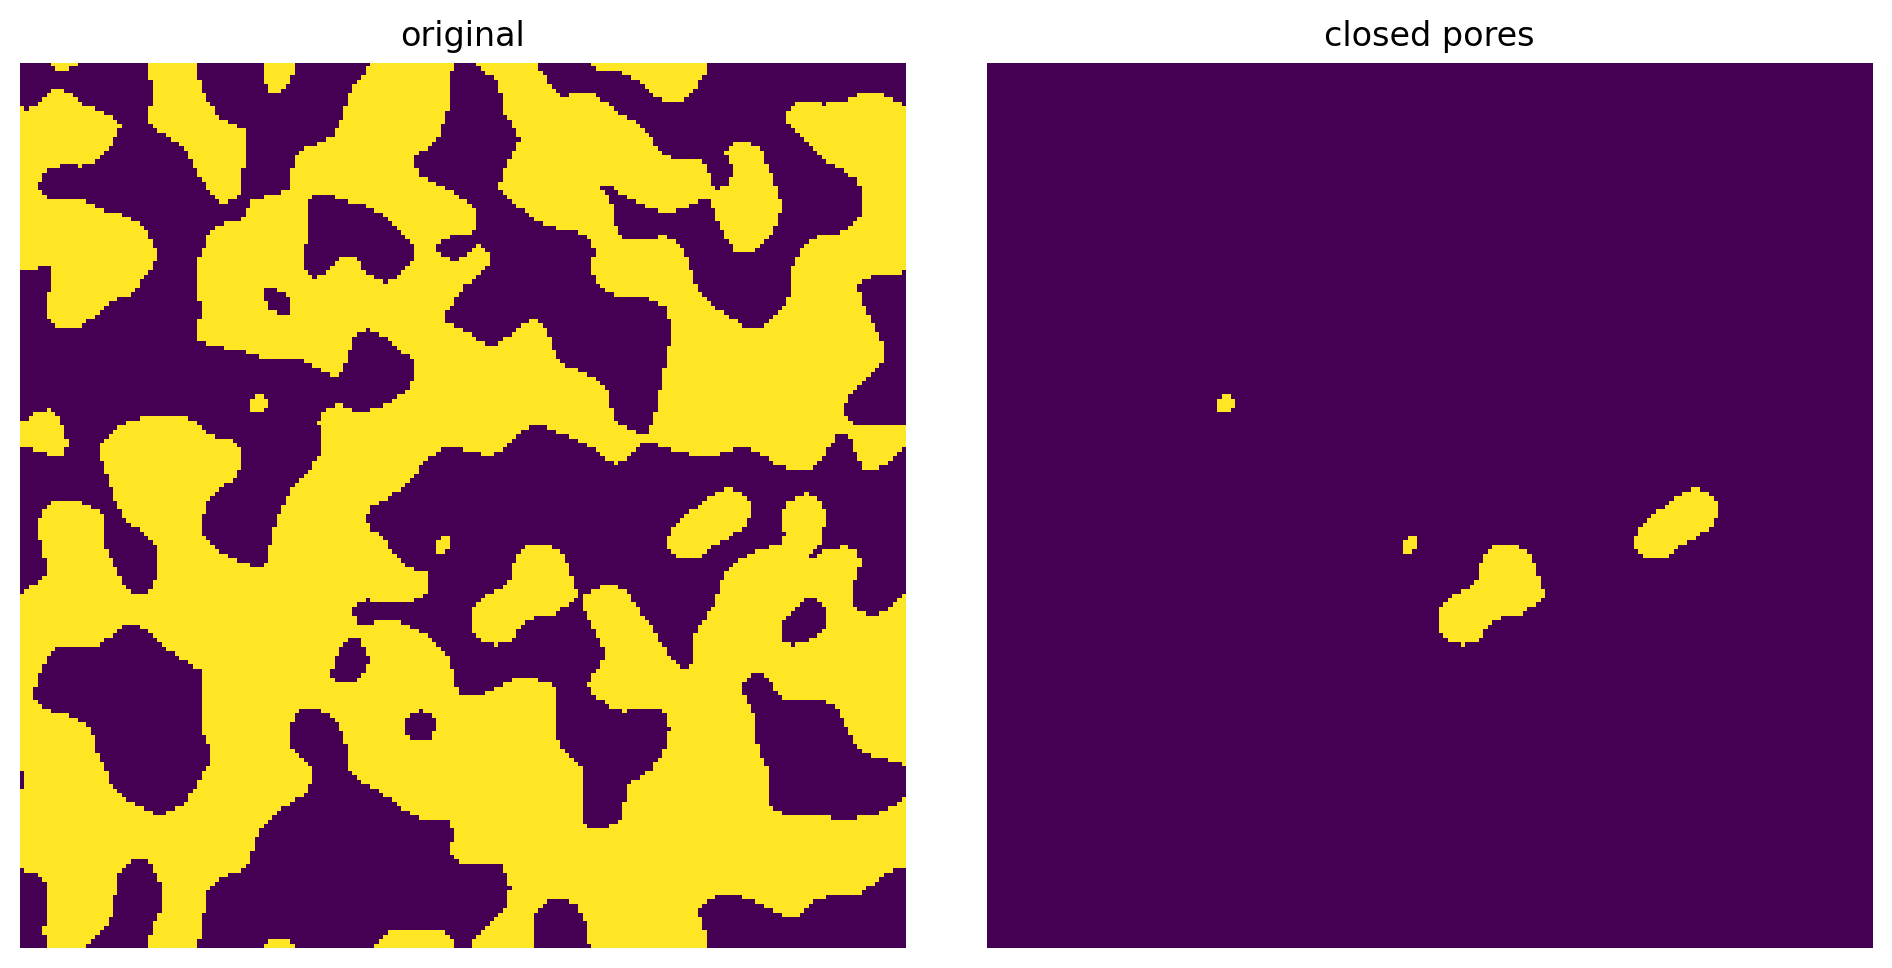

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.55, seed=0)
closed = ps.filters.find_closed_pores(im=im)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(im, origin='lower', interpolation='none')
ax[0].set_title('original')
ax[0].axis(False)
ax[1].imshow(closed, origin='lower', interpolation='none')
ax[1].set_title('closed pores')
ax[1].axis(False);

## `conn`
Controls voxel connectivity. `'min'` (default) considers voxels connected only if they share a face; `'max'` also considers edges and corners. Looser connectivity merges some clusters together, so fewer voxels appear closed.

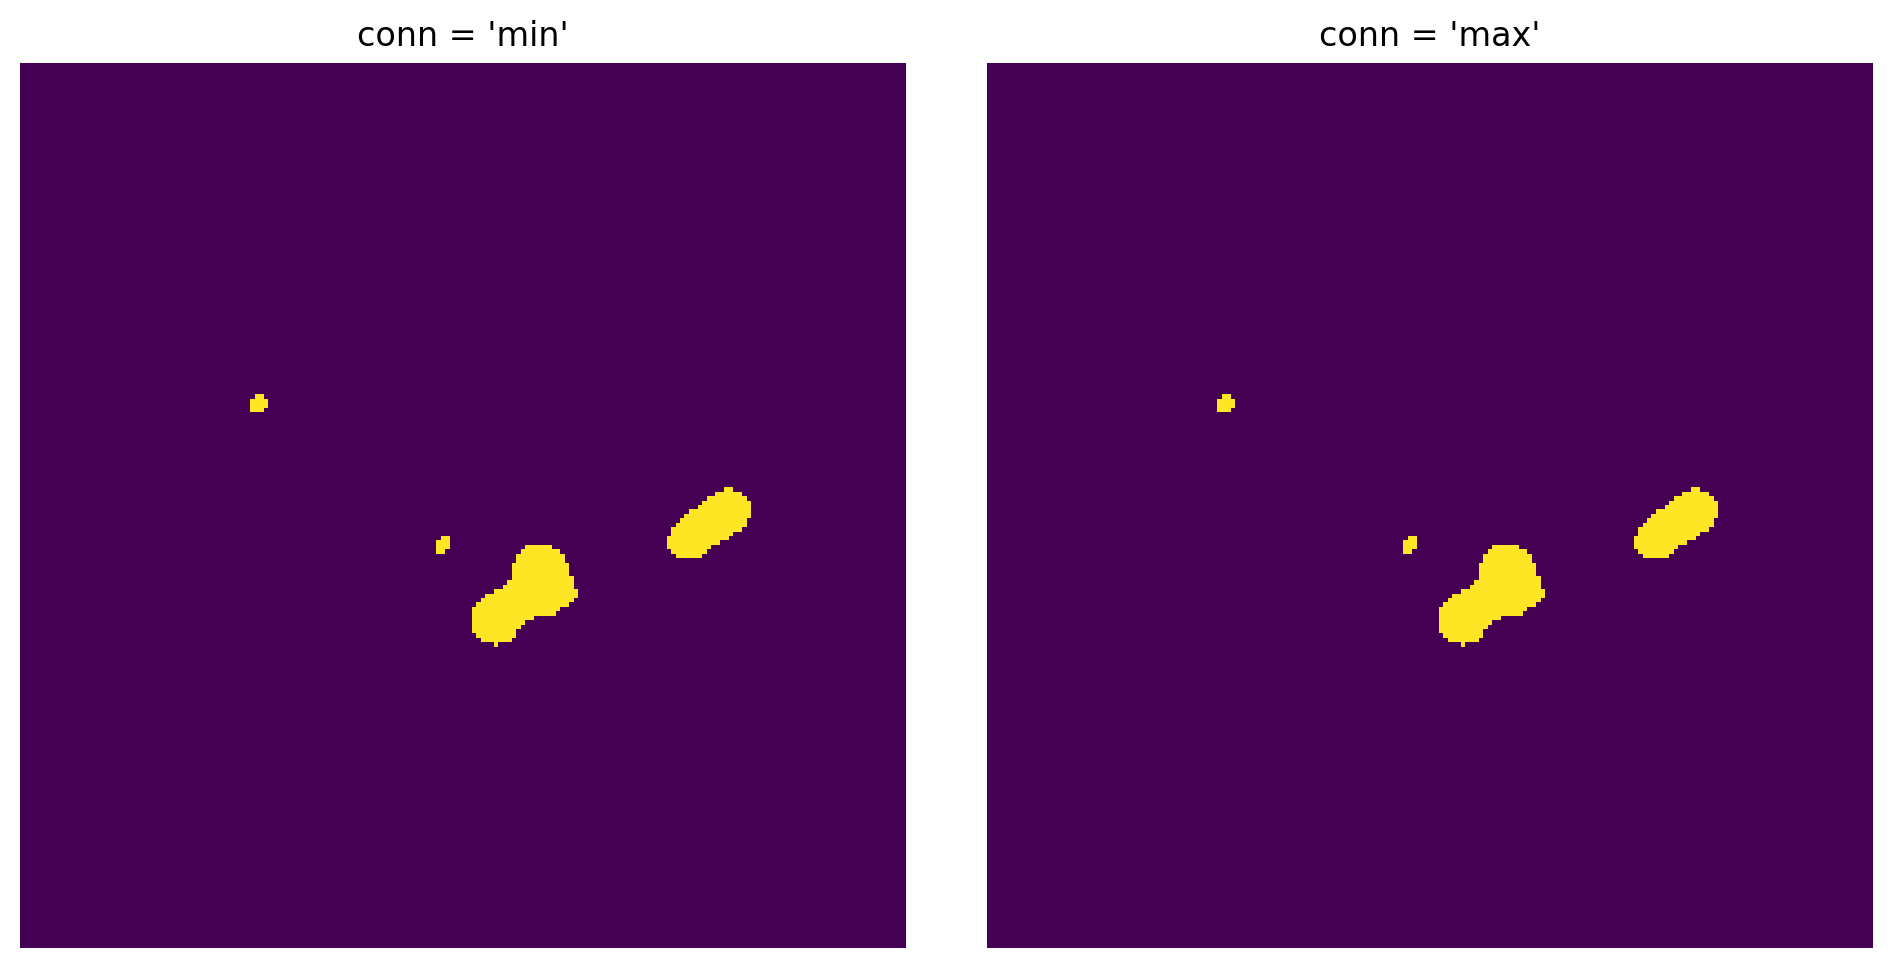

In [4]:
closed_min = ps.filters.find_closed_pores(im=im, conn='min')
closed_max = ps.filters.find_closed_pores(im=im, conn='max')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(closed_min, origin='lower', interpolation='none')
ax[0].set_title("conn = 'min'")
ax[0].axis(False)
ax[1].imshow(closed_max, origin='lower', interpolation='none')
ax[1].set_title("conn = 'max'")
ax[1].axis(False);